In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
import matplotlib as mpl
import matplotlib.font_manager as font_manager
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator)
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib import rcParams
import matplotlib.colors as mcolors
plt.rc('font',family='serif')
plt.rc('xtick',labelsize=18)
plt.rc('ytick',labelsize=18)
plt.rc('axes',labelsize=20)
plt.rc('axes',titlesize=20)
plt.rc('legend',fontsize=16)
plt.rc('lines', linewidth=2)
plt.rc('savefig', dpi=300)

plt.rcParams['figure.autolayout'] =  True
plt.rcParams["font.family"] = "Serif"
cmfont = font_manager.FontProperties(fname=mpl.get_data_path() + '/fonts/ttf/cmr10.ttf')
mpl.rcParams['font.serif']=cmfont.get_name()
mpl.rcParams['mathtext.fontset']='cm'
mpl.rcParams['axes.unicode_minus']=False
plt.rcParams['figure.figsize'] = [10, 8]
colors = list(mcolors.TABLEAU_COLORS.values())
# colors = ['steelblue', 'darkorange', 'olivedrab', 'firebrick']

In [4]:
trial_labels = [
    "o-FE",
    r"GHF",
    r"$S^2$-GHF",
    r"(SG, $S^2$)-GHF",
    r"($K$, SG, $S^2$)-GHF",
]

ene_4_exact = -15.56042333
ene_4 = [
    -15.582, # o-FE
    -15.442, # GHF
    -15.290, # S2-GHF
    -15.558, # (SG, S2)-GHF
    -15.558, # (K, SG, S2)-GHF
]
ene_4_serr = [
    0.002, # o-FE
    0.004, # GHF
    0.002, # S2-GHF
    0.001, # (SG, S2)-GHF
    0.001, # (K, SG, S2)-GHF
]

ene_8_exact = -8.47054398
ene_8 = [
    -8.549, # o-FE
    -7.82, # GHF
    -8.319, # S2-GHF
    -8.325, # (SG, S2)-GHF
    -8.383, # (K, SG, S2)-GHF, better converged VAP.
]
ene_8_serr = [
    0.008, # o-FE
    0.01, # GHF
    0.002, # S2-GHF
    0.003, # (SG, S2)-GHF   
    0.002, # (K, SG, S2)-GHF, better converged VAP.
]

ene_12_exact = -5.77723908
ene_12 = [
    -5.43, # o-FE
    -5.392, # GHF
    -5.685, # S2-GHF
    -5.717, # (SG, S2)-GHF
    -5.734, # (K, SG, S2)-GHF
]
ene_12_serr = [
    0.01, # o-FE
    0.009, # GHF
    0.002, # S2-GHF
    0.005, # (SG, S2)-GHF
    0.003, # (K, SG, S2)-GHF
] 

/var/folders/7s/34k_vnn90590lbb66qchz3c80000gn/T/ipykernel_27005/477265435.py:17: UserWarning: cmr10 font should ideally be used with mathtext, set axes.formatter.use_mathtext to True
  fig, ax1 = plt.subplots(
/var/folders/7s/34k_vnn90590lbb66qchz3c80000gn/T/ipykernel_27005/477265435.py:58: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


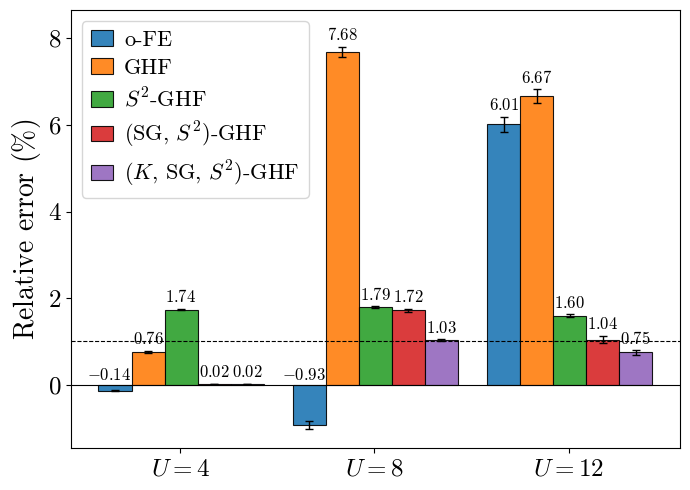

In [5]:
energies = np.array([ene_4, ene_8, ene_12])
energies_serr = np.array([ene_4_serr, ene_8_serr, ene_12_serr])
exact = np.array([ene_4_exact, ene_8_exact, ene_12_exact])[:, None]

energy_err_pct = 100.0 * (energies - exact) / np.abs(exact)
energy_err_pct_serr = 100.0 * energies_serr / np.abs(exact)

U_vals = [4, 8, 12]
trial_labels = [
    "o-FE",
    r"GHF",
    r"$S^2$-GHF",
    r"(SG, $S^2$)-GHF",
    r"($K$, SG, $S^2$)-GHF",
]

fig, ax1 = plt.subplots(
    1, 1, figsize=(7, 5), constrained_layout=True
)

x = np.arange(len(U_vals))
bar_width = 0.17
offsets = (np.arange(len(trial_labels)) - 1.5) * bar_width

# colors = [f"C{i}" for i in range(len(trial_labels))]

for i, (label, offset, color) in enumerate(zip(trial_labels, offsets, colors)):
    ax1.bar(
        x + offset,
        energy_err_pct[:, i],
        width=bar_width,
        yerr=energy_err_pct_serr[:, i],
        capsize=3,
        error_kw={'elinewidth': 1},
        edgecolor='k',
        linewidth=0.8,
        label=label,
        color=color,
        alpha=0.9,
    )

    for ix, x_val in enumerate(x):
        y = np.around(energy_err_pct[ix, i], 3)
        if y < 0.: ax1.text(x_val + offset - 0.03, 0.1, r'${:.2f}$'.format(y), ha='center', fontsize=12)
        else: ax1.text(x_val + offset, energy_err_pct[ix, i] + energy_err_pct_serr[ix, i] + 0.15, r'${:.2f}$'.format(y), ha='center', fontsize=12)

ymin, ymax = ax1.get_ylim()
ax1.set_ylim(ymin, ymax * 1.05)

ax1.axhline(0.0, color="k", linewidth=0.8)
ax1.axhline(1.0, color="k", linestyle="--", linewidth=0.8)
ax1.set_ylabel(r"Relative error ($\%$)")
ax1.legend(handlelength=1, labelspacing=0.4, handletextpad=0.5)

ax1.set_xticks(x + 0.08)
ax1.set_xticklabels([f"$U={U}$" for U in U_vals])

plt.tight_layout()
# plt.savefig('../figs/xc_4x4_symm_projection.pdf', format='pdf', dpi=300)